Group member:
Janvi thakre 02 B4-B1
Shweta Rahate 44 B4-B3
section: B4

Topic: Water Quality Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("water_purification_dataset.csv")

In [3]:
df.head()

,pH,turbidity_NTU,TDS_ppm,flow_rate_L_min,pressure_bar,temperature_C,usage_L_per_day,days_since_filter_change,water_quality,filter_replacement,maintenance_required
0,7.14,7.62,401,0.69,1.52,27.8,22,170,1,1,0
1,8.84,0.29,166,1.34,1.28,18.3,11,119,1,0,1
2,8.23,0.33,464,0.83,4.58,32.3,28,45,0,1,0
3,7.87,3.36,378,0.92,1.73,27.2,10,125,0,1,0
4,6.46,4.95,723,0.85,4.28,18.1,47,14,1,0,1


In [4]:
df.tail()

,pH,turbidity_NTU,TDS_ppm,flow_rate_L_min,pressure_bar,temperature_C,usage_L_per_day,days_since_filter_change,water_quality,filter_replacement,maintenance_required
1195,8.63,3.36,689,0.95,3.75,25.8,37,125,1,1,0
1196,8.92,1.53,299,0.76,3.06,17.7,32,110,1,1,0
1197,8.93,0.24,605,1.63,4.01,30.3,25,37,1,0,0
1198,8.26,6.51,438,0.63,2.96,33.8,44,21,1,1,1
1199,6.45,6.42,694,1.47,1.55,33.7,48,14,1,0,1


In [5]:
df.shape

(1200, 11)

In [6]:
df.size

13200

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pH                        1200 non-null   float64
 1   turbidity_NTU             1200 non-null   float64
 2   TDS_ppm                   1200 non-null   int64  
 3   flow_rate_L_min           1200 non-null   float64
 4   pressure_bar              1200 non-null   float64
 5   temperature_C             1200 non-null   float64
 6   usage_L_per_day           1200 non-null   int64  
 7   days_since_filter_change  1200 non-null   int64  
 8   water_quality             1200 non-null   int64  
 9   filter_replacement        1200 non-null   int64  
 10  maintenance_required      1200 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 103.3 KB


In [8]:
df.describe()

,pH,turbidity_NTU,TDS_ppm,flow_rate_L_min,pressure_bar,temperature_C,usage_L_per_day,days_since_filter_change,water_quality,filter_replacement,maintenance_required
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,7.499192,5.034192,550.238333,1.233150,2.993117,24.905250,26.638333,89.315000,1.236667,0.609167,0.384167
std,0.886258,2.852493,259.641733,0.431213,1.159409,5.767411,12.828276,52.193575,0.675304,0.488141,0.486600
min,6.000000,0.100000,100.000000,0.500000,1.000000,15.000000,5.000000,1.000000,0.000000,0.000000,0.000000
25%,6.720000,2.522500,328.750000,0.860000,1.987500,19.875000,16.000000,45.000000,1.000000,0.000000,0.000000
50%,7.520000,5.080000,550.000000,1.220000,2.960000,24.800000,26.000000,89.000000,1.000000,1.000000,0.000000
75%,8.262500,7.462500,777.000000,1.590000,3.982500,30.025000,37.000000,135.000000,2.000000,1.000000,1.000000
max,9.000000,10.000000,1000.000000,2.000000,5.000000,35.000000,50.000000,179.000000,2.000000,1.000000,1.000000


In [9]:
df.isnull().sum()

pH                          0
turbidity_NTU               0
TDS_ppm                     0
flow_rate_L_min             0
pressure_bar                0
temperature_C               0
usage_L_per_day             0
days_since_filter_change    0
water_quality               0
filter_replacement          0
maintenance_required        0
dtype: int64

In [10]:
# Handling missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df[df.columns] = imputer.fit_transform(df)
print("After imputation:\n", df.isnull().sum())

After imputation:
pH                          0
turbidity_NTU               0
TDS_ppm                     0
flow_rate_L_min             0
pressure_bar                0
temperature_C               0
usage_L_per_day             0
days_since_filter_change    0
water_quality               0
filter_replacement          0
maintenance_required        0
dtype: int64


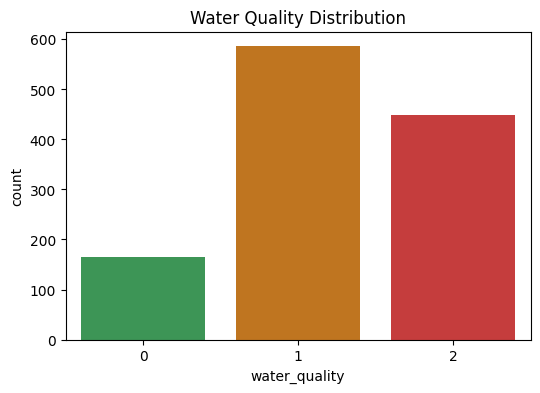

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='water_quality', data=df)
plt.title("Water Quality Distribution")
plt.show()

This helps understand range and spread of features like pH, TDS, turbidity.

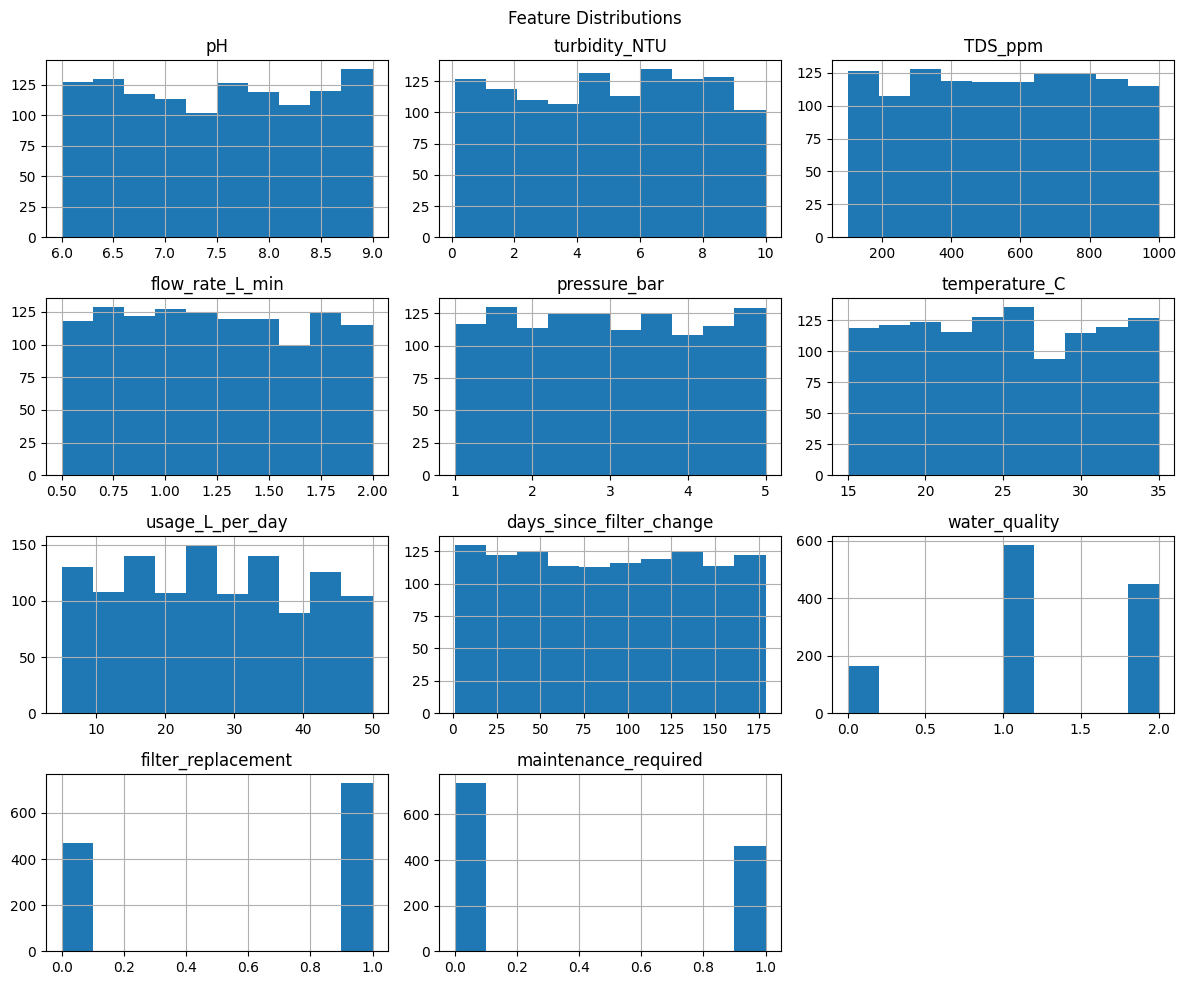

In [12]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

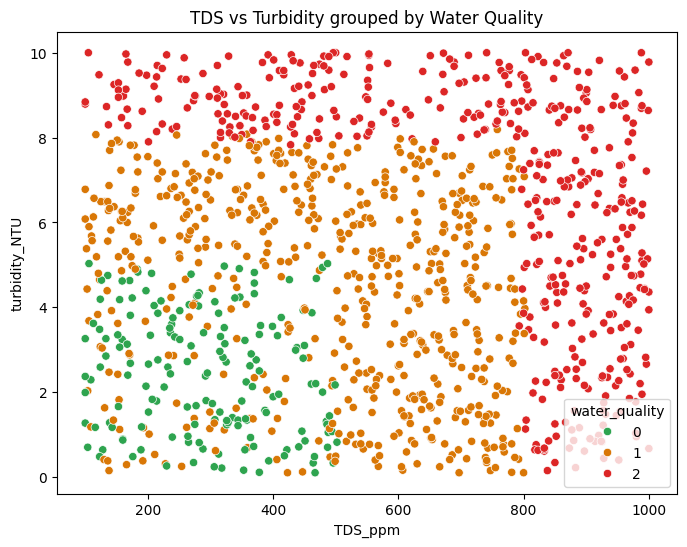

In [13]:
sns.scatterplot(x='TDS_ppm', y='turbidity_NTU', hue='water_quality', data=df)
plt.show()

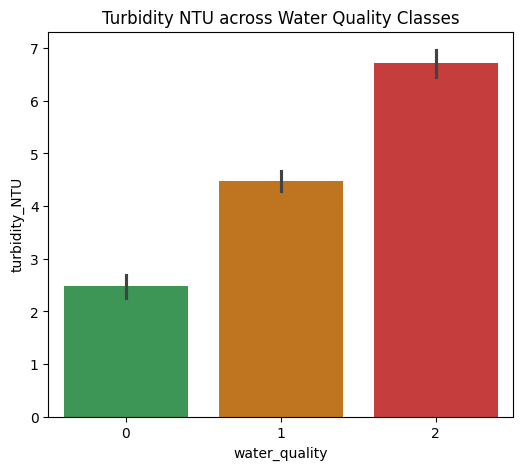

In [14]:
sns.barplot(x='water_quality', y='turbidity_NTU', data=df)
plt.show()

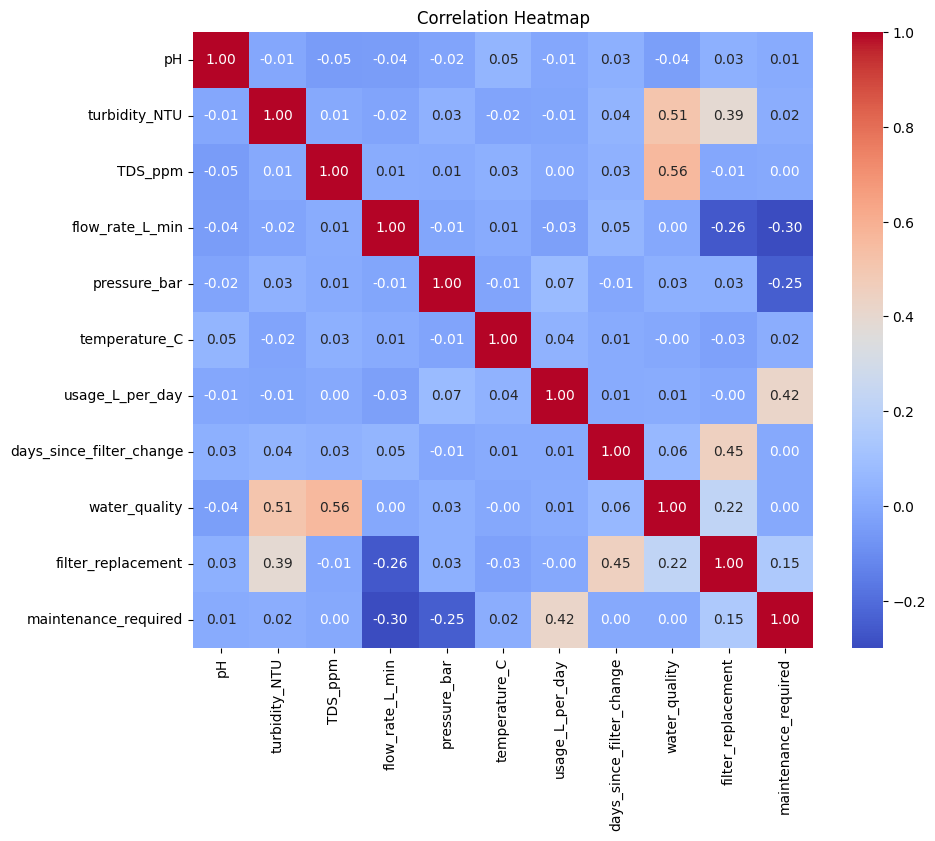

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
X = df.drop(columns=["water_quality", "filter_replacement", "maintenance_required"])
y = df["water_quality"]

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=4, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

model_scores = {}

In [17]:
for name, model in models.items():
    if "Forest" in name or "Tree" in name:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    model_scores[name] = acc
    print(f"\n{name} Accuracy: {acc}")
    print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.7041666666666667
              precision    recall  f1-score   support

           0       0.74      0.42      0.54        33
           1       0.66      0.80      0.73       117
           2       0.77      0.68      0.72        90

    accuracy                           0.70       240
   macro avg       0.72      0.64      0.66       240
weighted avg       0.71      0.70      0.70       240

Decision Tree Accuracy: 0.9541666666666667
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        33
           1       0.94      0.97      0.95       117
           2       0.97      0.96      0.96        90

    accuracy                           0.95       240
   macro avg       0.96      0.94      0.95       240
weighted avg       0.95      0.95      0.95       240

Random Forest Accuracy: 0.9416666666666667
              precision    recall  f1-score   support

           0       0.96      0.82      0.89     

In [18]:
best_model_name = max(model_scores, key=model_scores.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Accuracy:", model_scores[best_model_name])

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
print("\nCross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Best Model: Decision Tree
Best Accuracy: 0.9541666666666667

Cross Validation Scores: [0.953125   0.95833333 0.96354167 0.94270833 0.953125  ]
Mean CV Accuracy: 0.9541666666666668


In [19]:
# HYPERPARAMETER TUNING
if best_model_name == "Decision Tree":
    params = {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10]}
    grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    final_model = grid.best_estimator_
elif best_model_name == "Random Forest":
    params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 4, 5]}
    grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    final_model = grid.best_estimator_
else:
    final_model = best_model

print(f"\nBest Parameters ({best_model_name}):", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters (Decision Tree): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.9552083333333332


In [20]:
y_pred = final_model.predict(X_test)
print("\nFinal Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nFinal Classification Report:\n", classification_report(y_test, y_pred))


Final Test Accuracy: 0.9416666666666667

Final Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.91      0.97      0.94       117
           2       0.98      0.94      0.96        90

    accuracy                           0.94       240
   macro avg       0.95      0.91      0.93       240
weighted avg       0.94      0.94      0.94       240



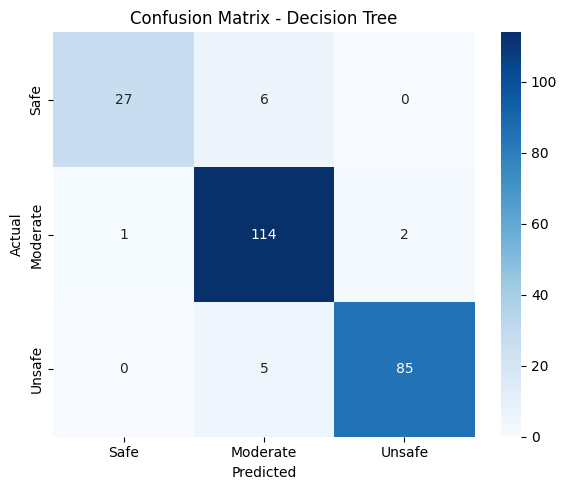

In [21]:
cm = confusion_matrix(y_test, y_pred)
labels = ["Safe", "Moderate", "Unsafe"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()